# RFM Customer Segmentation Using K-Means

This notebook builds a business-oriented RFM segmentation model on cleaned invoice data and applies K-Means clustering to identify meaningful customer groups.


## 1. Imports and Setup


In [2]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score, silhouette_score
from sklearn.preprocessing import StandardScaler

sns.set_theme(style='whitegrid')
warnings.filterwarnings('ignore')
pd.options.display.float_format = '{:,.2f}'.format

## 2. Load the Dataset

The cleaned dataset is loaded from the project workspace. The `Date` column is parsed into datetime format, and a first check is performed on the dataset size, period covered, number of clients, and available columns.


In [3]:
# ?? Paths ??
project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent
if project_root.name == "rfm_ml_project":
    repo_root = project_root.parent
else:
    repo_root = project_root

candidate_data_paths = [
    repo_root / "data" / "processed" / "cleaned_data.csv",
    project_root / "data" / "processed" / "cleaned_data.csv",
    project_root / "data" / "cleaned_data.csv",
]

data_path = next((p for p in candidate_data_paths if p.exists()), None)
if data_path is None:
    tried = "\n".join(str(p) for p in candidate_data_paths)
    raise FileNotFoundError(f"cleaned_data.csv not found. Checked:\n{tried}")

output_dir = project_root / "notebooks" / "outputs" / "figures"
output_dir.mkdir(parents=True, exist_ok=True)

tables_output_dir = output_dir.parent / "tables"
tables_output_dir.mkdir(parents=True, exist_ok=True)

# ?? Load Data ??
for encoding in ('utf-8-sig', 'cp1252'):
    try:
        df = pd.read_csv(data_path, encoding=encoding)
        print(f"Data loaded from: {data_path}")
        print(f"Data loaded with encoding: {encoding}")
        break
    except UnicodeDecodeError:
        continue
else:
    raise UnicodeDecodeError('cleaned_data.csv', b'', 0, 1, 'Unable to decode file')

# ?? Columns ??
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
invoice_col = 'Num?ro de facture'
monetary_col = 'Net ? Payer'



Data loaded from: c:\Users\H-Info\OneDrive\Desktop\graduation_project\facture2425 rfm model\data\processed\cleaned_data.csv
Data loaded with encoding: utf-8-sig


In [4]:
print(df.columns.tolist())

['Date', 'Numéro de facture', 'Raison Sociale', 'Net à Payer', 'Règlement', 'Reste à payer', 'Code Client', 'Solde global', 'Année', 'Mois', 'Mois_Nom']


## 3. Remove Anonymous Client

The client code `AA000002` represents anonymous or unattributed sales. It is removed because the objective of RFM segmentation is to analyze identified customers.


In [5]:
rows_before = len(df)
df = df[df['Code Client'] != 'AA000002'].copy()
rows_removed = rows_before - len(df)

print('Rows removed for client AA000002:', rows_removed)
print('Remaining shape:', df.shape)

Rows removed for client AA000002: 26697
Remaining shape: (34848, 11)


## 4. Build the Global RFM Table

A global RFM table is created at the customer level. For each client, the notebook computes the last purchase date, recency, purchase frequency, and total monetary value.


In [6]:
def compute_rfm(dataframe):
    invoice_col  = 'Numéro de facture'
    monetary_col = 'Net à Payer'

    analysis_date = dataframe['Date'].max() + pd.Timedelta(days=1)

    rfm = (
        dataframe
        .groupby(['Code Client', 'Raison Sociale'], dropna=False)
        .agg(
            LastPurchaseDate = ('Date',        'max'),
            Frequency        = (invoice_col,   'nunique'),
            Monetary         = (monetary_col,  'sum')
        )
        .reset_index()
    )

    rfm['Recency'] = (analysis_date - rfm['LastPurchaseDate']).dt.days

    rfm = rfm[[
        'Code Client',
        'Raison Sociale',
        'LastPurchaseDate',
        'Recency',
        'Frequency',
        'Monetary'
    ]].copy()

    return rfm

rfm_global = compute_rfm(df)

print('rfm_global shape:', rfm_global.shape)
rfm_global.head()

rfm_global shape: (330, 6)


,Code Client,Raison Sociale,LastPurchaseDate,Recency,Frequency,Monetary
0,AA000001,AATEF MED,2025-09-18,105,5,"28,715.18"
1,AB000004,ABD EL REZAK MAACHE,2024-06-15,565,61,"1,536,546.87"
2,AB000005,ABDASSALEM ABK,2025-12-31,1,679,"8,387,229.83"
3,AB000009,ABZOUZI MOHAMED,2025-12-31,1,338,"1,178,668.31"
4,AB000011,ABD EL MALEK RABEH BEL HOUARI,2024-12-29,368,2,"53,824.10"


In [7]:
rfm_global[["Recency", "Frequency", "Monetary"]].describe()

,Recency,Frequency,Monetary
count,330.00,330.00,330.00
mean,170.25,105.32,"1,359,251.08"
std,226.60,153.79,"2,933,706.77"
min,1.00,1.00,85.00
25%,3.00,6.00,"54,119.41"
50%,29.00,40.00,"378,734.94"
75%,308.75,147.00,"1,467,668.25"
max,729.00,753.00,"38,089,280.80"


## 5. Filter Low-Value and One-Time Clients

For the clustering stage, very small or unstable customers are excluded using the conditions `Frequency >= 2` and `Monetary >= 1000`. This keeps the analysis focused on economically meaningful and behaviorally stable clients.


In [8]:
rfm_global_filtered = rfm_global[
    (rfm_global["Frequency"] >= 2) &
    (rfm_global["Monetary"] >= 1000)
].copy()

print("Original number of clients:", rfm_global.shape[0])
print("Filtered number of clients:", rfm_global_filtered.shape[0])

rfm_global_filtered[["Recency", "Frequency", "Monetary"]].describe()

Original number of clients: 330
Filtered number of clients: 294


,Recency,Frequency,Monetary
count,294.00,294.00,294.00
mean,145.13,118.09,"1,523,795.99"
std,213.36,158.29,"3,068,394.42"
min,1.00,2.00,"2,820.12"
25%,3.00,13.25,"113,019.96"
50%,18.00,59.00,"503,663.25"
75%,234.25,155.00,"1,777,117.56"
max,729.00,753.00,"38,089,280.80"


<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>Recency</th>
      <th>Frequency</th>
      <th>Monetary</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>count</th>
      <td>294.00</td>
      <td>294.00</td>
      <td>294.00</td>
    </tr>
    <tr>
      <th>mean</th>
      <td>145.13</td>
      <td>118.09</td>
      <td>1,523,795.99</td>
    </tr>
    <tr>
      <th>std</th>
      <td>213.36</td>
      <td>158.29</td>
      <td>3,068,394.42</td>
    </tr>
    <tr>
      <th>min</th>
      <td>1.00</td>
      <td>2.00</td>
      <td>2,820.12</td>
    </tr>
    <tr>
      <th>25%</th>
      <td>3.00</td>
      <td>13.25</td>
      <td>113,019.96</td>
    </tr>
    <tr>
      <th>50%</th>
      <td>18.00</td>
      <td>59.00</td>
      <td>503,663.25</td>
    </tr>
    <tr>
      <th>75%</th>
      <td>234.25</td>
      <td>155.00</td>
      <td>1,777,117.56</td>
    </tr>
    <tr>
      <th>max</th>
      <td>729.00</td>
      <td>753.00</td>
      <td>38,089,280.80</td>
    </tr>
  </tbody>
</table>
</div>


<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>Recency</th>
      <th>Frequency</th>
      <th>Monetary</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>count</th>
      <td>294.00</td>
      <td>294.00</td>
      <td>294.00</td>
    </tr>
    <tr>
      <th>mean</th>
      <td>145.13</td>
      <td>118.09</td>
      <td>1,523,795.99</td>
    </tr>
    <tr>
      <th>std</th>
      <td>213.36</td>
      <td>158.29</td>
      <td>3,068,394.42</td>
    </tr>
    <tr>
      <th>min</th>
      <td>1.00</td>
      <td>2.00</td>
      <td>2,820.12</td>
    </tr>
    <tr>
      <th>25%</th>
      <td>3.00</td>
      <td>13.25</td>
      <td>113,019.96</td>
    </tr>
    <tr>
      <th>50%</th>
      <td>18.00</td>
      <td>59.00</td>
      <td>503,663.25</td>
    </tr>
    <tr>
      <th>75%</th>
      <td>234.25</td>
      <td>155.00</td>
      <td>1,777,117.56</td>
    </tr>
    <tr>
      <th>max</th>
      <td>729.00</td>
      <td>753.00</td>
      <td>38,089,280.80</td>
    </tr>
  </tbody>
</table>
</div>


## 6. Prepare Features for Clustering

Because K-Means is distance-based, feature preparation is required. `Frequency` and `Monetary` are log-transformed to reduce skewness, and the final clustering inputs are standardized.


In [9]:
rfm_model = rfm_global_filtered.copy()

rfm_model["Frequency_log"] = np.log1p(rfm_model["Frequency"])
rfm_model["Monetary_log"] = np.log1p(rfm_model["Monetary"])

features = rfm_model[["Recency", "Frequency_log", "Monetary_log"]].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

print("Shape of rfm_model:", rfm_model.shape)
print("Shape of X_scaled:", X_scaled.shape)

rfm_model.head()

Shape of rfm_model: (294, 8)
Shape of X_scaled: (294, 3)


,Code Client,Raison Sociale,LastPurchaseDate,Recency,Frequency,Monetary,Frequency_log,Monetary_log
0,AA000001,AATEF MED,2025-09-18,105,5,"28,715.18",1.79,10.27
1,AB000004,ABD EL REZAK MAACHE,2024-06-15,565,61,"1,536,546.87",4.13,14.25
2,AB000005,ABDASSALEM ABK,2025-12-31,1,679,"8,387,229.83",6.52,15.94
3,AB000009,ABZOUZI MOHAMED,2025-12-31,1,338,"1,178,668.31",5.83,13.98
4,AB000011,ABD EL MALEK RABEH BEL HOUARI,2024-12-29,368,2,"53,824.10",1.10,10.89


## 7. Determine the Optimal Number of Clusters

Several values of `k` are tested using inertia and silhouette score. Although the highest silhouette score is obtained for `k = 2`, larger values are also reviewed to improve business interpretability.


In [10]:
def find_optimal_k(X_scaled, k_range=range(2, 9)):
    results = []

    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
        labels = kmeans.fit_predict(X_scaled)

        results.append({
            "k": k,
            "inertia": kmeans.inertia_,
            "silhouette_score": silhouette_score(X_scaled, labels)
        })

    return pd.DataFrame(results)

k_results = find_optimal_k(X_scaled)
k_results

,k,inertia,silhouette_score
0,2,384.27,0.51
1,3,256.37,0.45
2,4,191.22,0.38
3,5,148.73,0.40
4,6,116.29,0.39
5,7,104.05,0.38
6,8,93.27,0.39


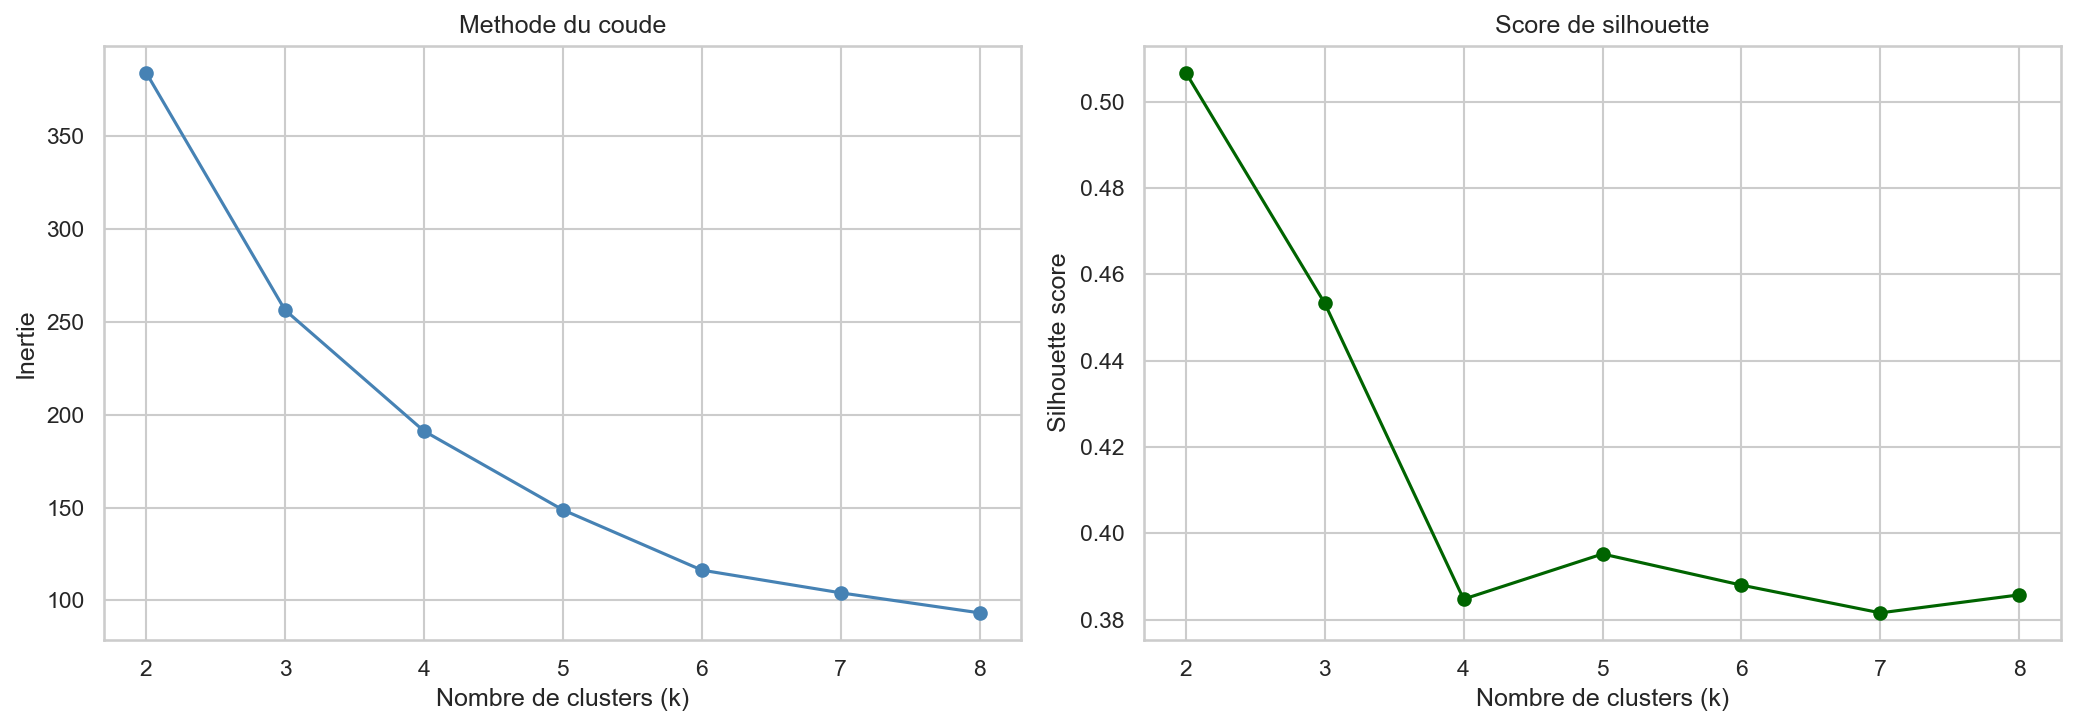

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=150)

axes[0].plot(k_results["k"], k_results["inertia"], marker="o", color="steelblue")
axes[0].set_title("Methode du coude")
axes[0].set_xlabel("Nombre de clusters (k)")
axes[0].set_ylabel("Inertie")

axes[1].plot(k_results["k"], k_results["silhouette_score"], marker="o", color="darkgreen")
axes[1].set_title("Score de silhouette")
axes[1].set_xlabel("Nombre de clusters (k)")
axes[1].set_ylabel("Silhouette score")

plt.tight_layout()
plt.show()

The 4-cluster solution was retained for the final model because it produced more actionable customer profiles than the 2-cluster solution, while remaining acceptable from a validation perspective.


In [12]:

#  test k = 4:

kmeans_4 = KMeans(n_clusters=4, random_state=42, n_init=20)
rfm_k4 = rfm_model.copy()
rfm_k4["Cluster"] = kmeans_4.fit_predict(X_scaled)

profile_k4 = (
    rfm_k4.groupby("Cluster")
    .agg(
        Avg_Recency=("Recency", "mean"),
        Avg_Frequency=("Frequency", "mean"),
        Avg_Monetary=("Monetary", "mean"),
        Client_Count=("Code Client", "count")
    )
    .sort_values("Avg_Monetary", ascending=False)
)

print("k = 4")
display(profile_k4)

k = 4


,Avg_Recency,Avg_Frequency,Avg_Monetary,Client_Count
Cluster,,,,
2,10.45,295.54,"4,163,399.00",87
0,54.11,70.02,"657,734.45",107
1,547.15,22.75,"241,159.67",53
3,148.30,6.55,"55,771.45",47


## 8. Fit the K-Means Model

The final K-Means model is fitted with `k = 4`. Each customer is assigned to a cluster, and each cluster is then translated into a business segment label.


In [13]:
best_k = 4

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=20)
rfm_model["Cluster"] = kmeans.fit_predict(X_scaled)

segment_map = {
    2: "Best Customers",
    0: "Loyal Customers",
    1: "Lost Customers",
    3: "At Risk Customers"
}

rfm_model["Segment"] = rfm_model["Cluster"].map(segment_map)

rfm_model[[
    "Code Client",
    "Raison Sociale",
    "Cluster",
    "Segment",
    "Recency",
    "Frequency",
    "Monetary"
]].head()

,Code Client,Raison Sociale,Cluster,Segment,Recency,Frequency,Monetary
0,AA000001,AATEF MED,3,At Risk Customers,105,5,"28,715.18"
1,AB000004,ABD EL REZAK MAACHE,1,Lost Customers,565,61,"1,536,546.87"
2,AB000005,ABDASSALEM ABK,2,Best Customers,1,679,"8,387,229.83"
3,AB000009,ABZOUZI MOHAMED,2,Best Customers,1,338,"1,178,668.31"
4,AB000011,ABD EL MALEK RABEH BEL HOUARI,3,At Risk Customers,368,2,"53,824.10"


## 9. Evaluate the Clustering Results

Clustering quality is evaluated with three common internal validation metrics: silhouette score, Davies-Bouldin index, and Calinski-Harabasz score.


In [14]:
sil = silhouette_score(X_scaled, rfm_model["Cluster"])
dbi = davies_bouldin_score(X_scaled, rfm_model["Cluster"])
chi = calinski_harabasz_score(X_scaled, rfm_model["Cluster"])

print("Silhouette score:", round(sil, 4))
print("Davies-Bouldin score:", round(dbi, 4))
print("Calinski-Harabasz score:", round(chi, 4))

Silhouette score: 0.3847
Davies-Bouldin score: 0.8817
Calinski-Harabasz score: 349.2108


- A higher silhouette score indicates better separation between clusters.
- A lower Davies-Bouldin score indicates more compact and distinct clusters.
- A higher Calinski-Harabasz score indicates stronger separation relative to within-cluster dispersion.


## 10. Profile and Label the Segments

Cluster profiling is based on average and median RFM values. The resulting groups are interpreted as `Best Customers`, `Loyal Customers`, `Lost Customers`, and `At Risk Customers`.


In [15]:
segment_profile = (
    rfm_model.groupby(["Cluster", "Segment"])
    .agg(
        Client_Count=("Code Client", "count"),
        Avg_Recency=("Recency", "mean"),
        Median_Recency=("Recency", "median"),
        Avg_Frequency=("Frequency", "mean"),
        Median_Frequency=("Frequency", "median"),
        Avg_Monetary=("Monetary", "mean"),
        Median_Monetary=("Monetary", "median")
    )
    .sort_values("Avg_Monetary", ascending=False)
)

display(segment_profile)

,,Client_Count,Avg_Recency,Median_Recency,Avg_Frequency,Median_Frequency,Avg_Monetary,Median_Monetary
Cluster,Segment,,,,,,,
2,Best Customers,87,10.45,2.00,295.54,211.00,"4,163,399.00","2,820,431.19"
0,Loyal Customers,107,54.11,12.00,70.02,62.00,"657,734.45","498,432.17"
1,Lost Customers,53,547.15,565.00,22.75,12.00,"241,159.67","109,918.80"
3,At Risk Customers,47,148.30,105.00,6.55,5.00,"55,771.45","38,959.24"


In [17]:
print(rfm_model.groupby(['Cluster', 'Segment'])['Code Client'].count().reset_index())

   Cluster            Segment  Code Client
0        0    Loyal Customers          107
1        1     Lost Customers           53
2        2     Best Customers           87
3        3  At Risk Customers           47


## 11. Visualize the Segments

The segmentation is visualized using bar charts, a 2D PCA projection, an interactive 3D chart, and a static 3D plot to support interpretation from multiple angles.


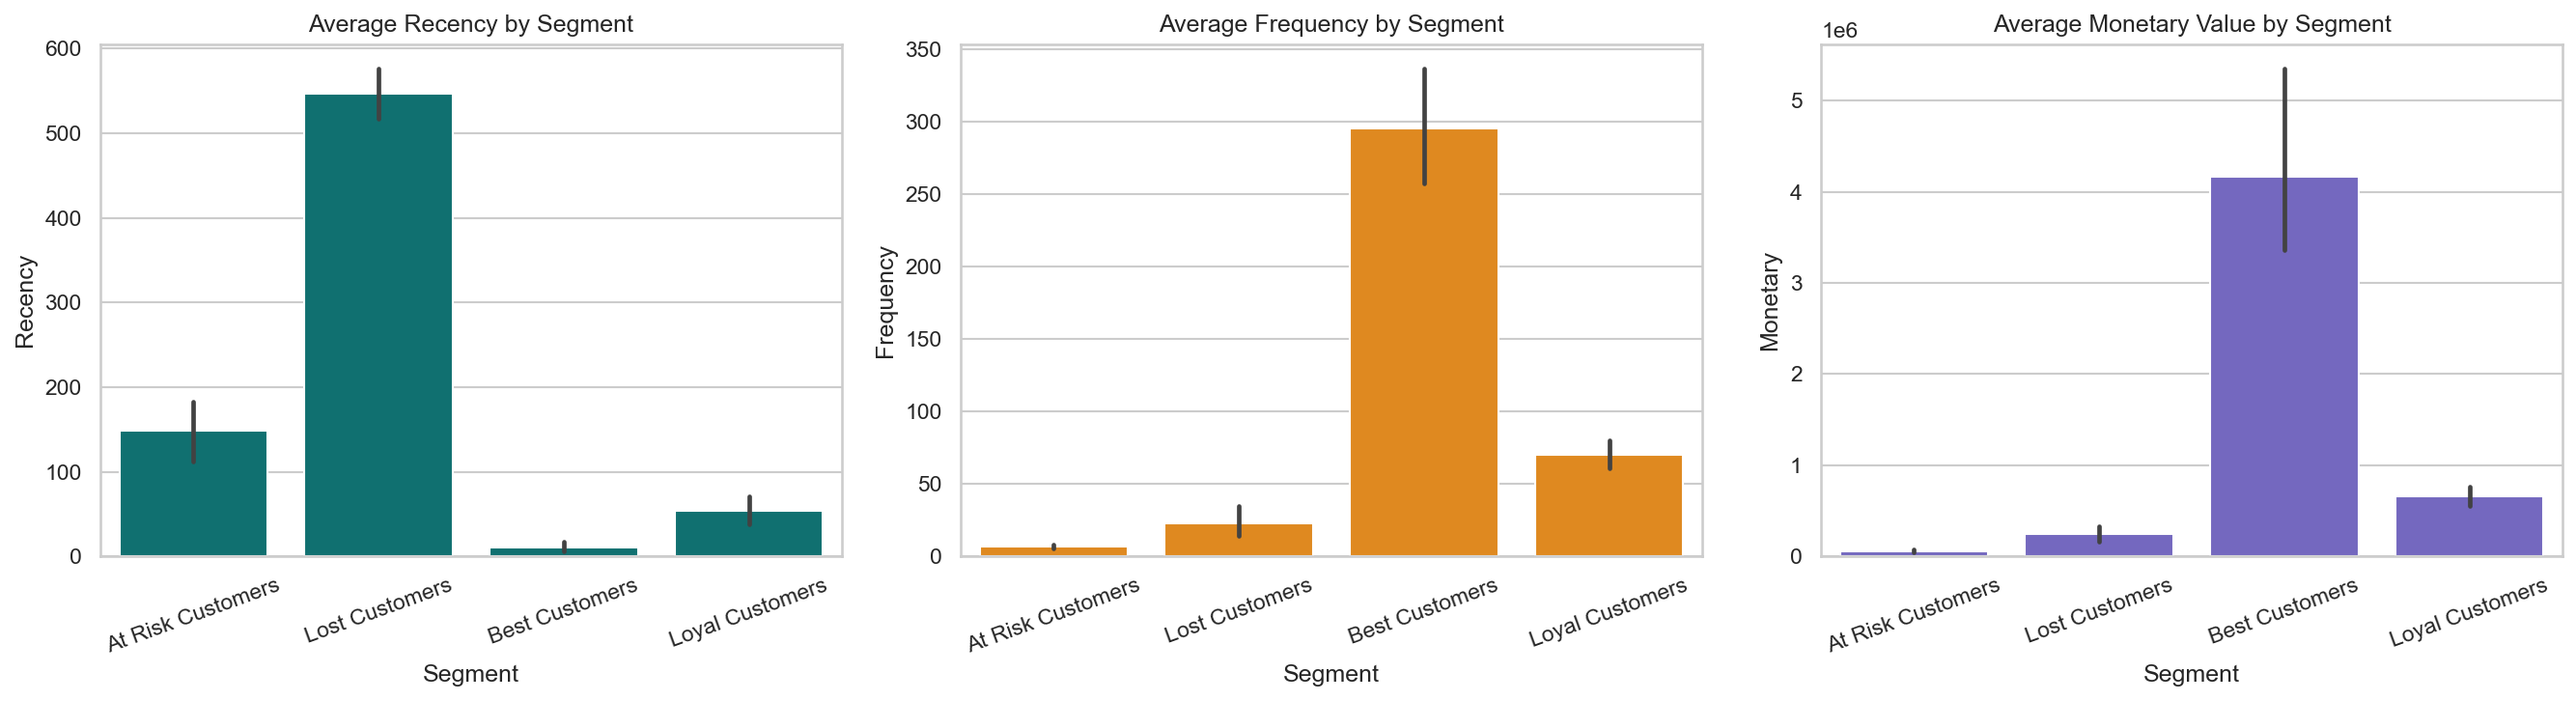

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=150)

sns.barplot(data=rfm_model, x="Segment", y="Recency", estimator=np.mean, ax=axes[0], color="teal")
axes[0].set_title("Average Recency by Segment")
axes[0].tick_params(axis="x", rotation=20)

sns.barplot(data=rfm_model, x="Segment", y="Frequency", estimator=np.mean, ax=axes[1], color="darkorange")
axes[1].set_title("Average Frequency by Segment")
axes[1].tick_params(axis="x", rotation=20)

sns.barplot(data=rfm_model, x="Segment", y="Monetary", estimator=np.mean, ax=axes[2], color="slateblue")
axes[2].set_title("Average Monetary Value by Segment")
axes[2].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

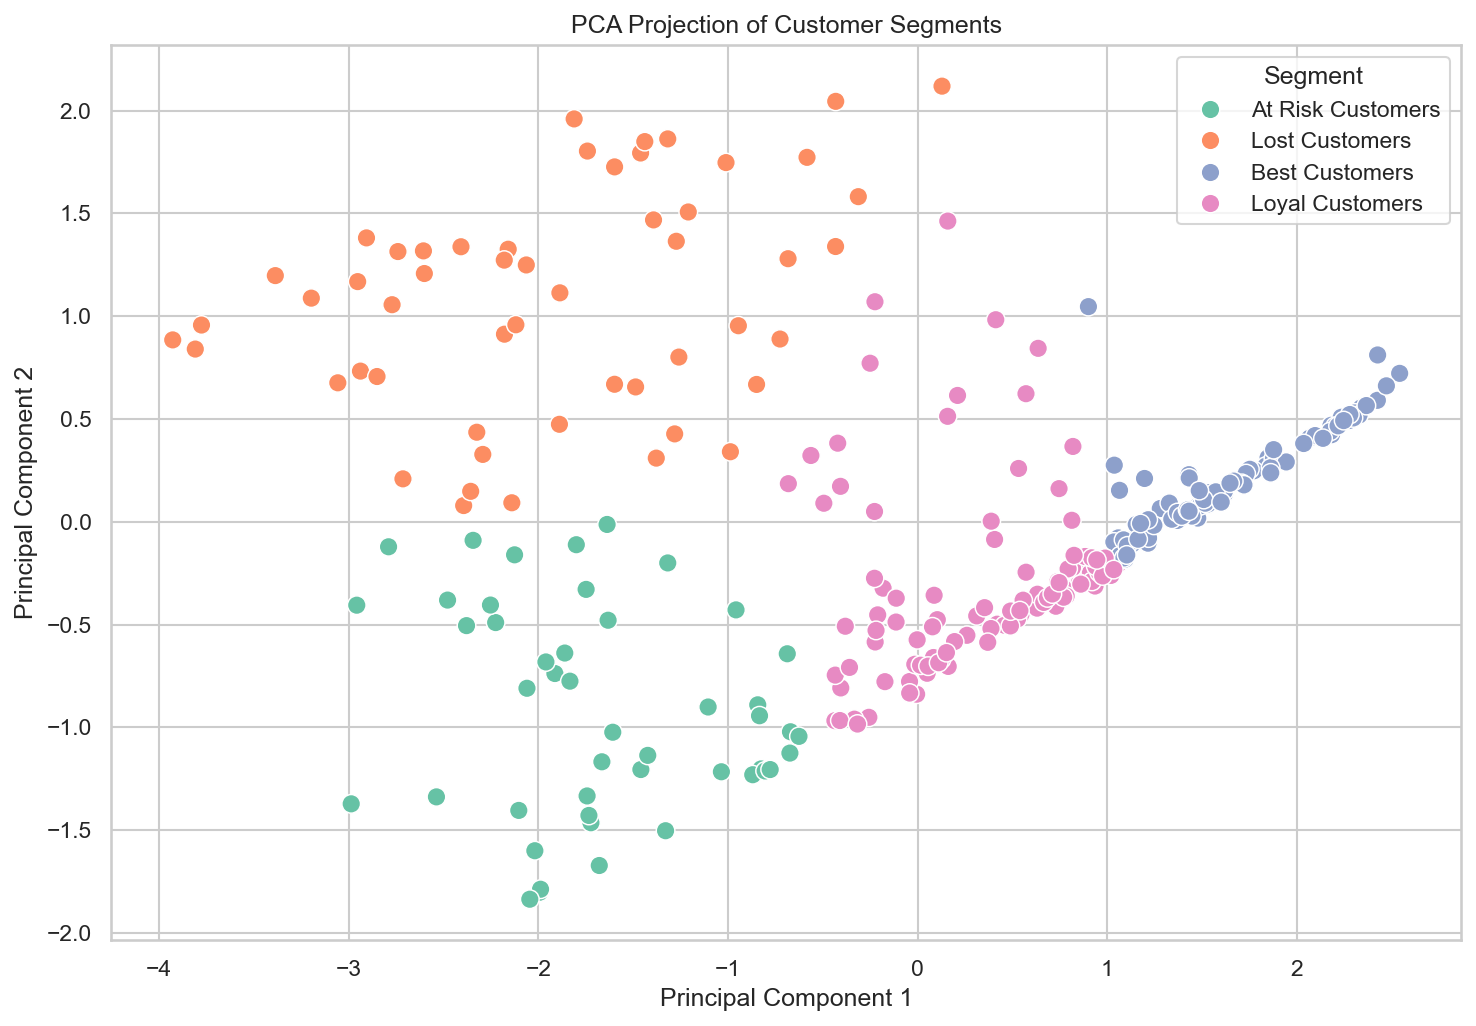

In [ ]:
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(coords, columns=["PC1", "PC2"])
pca_df["Cluster"] = rfm_model["Cluster"].values
pca_df["Segment"] = rfm_model["Segment"].values
pca_df["Code Client"] = rfm_model["Code Client"].values
pca_df["Raison Sociale"] = rfm_model["Raison Sociale"].values

plt.figure(figsize=(10, 7), dpi=150)
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Segment",
    palette="Set2",
    s=80
)

plt.title("PCA Projection of Customer Segments")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Segment")
plt.tight_layout()
plt.show()

In [ ]:
import plotly.express as px
import numpy as np

rfm_3d = rfm_model.reset_index(drop=True).copy()
rfm_3d["Recency_scaled"] = X_scaled[:, 0]
rfm_3d["Frequency_log_scaled"] = X_scaled[:, 1]
rfm_3d["Monetary_log_scaled"] = X_scaled[:, 2]

color_map = {
    "Best Customers": "#68ef68",
    "Loyal Customers": "#19a5d8",
    "Lost Customers": "#19163f",
    "At Risk Customers": "#7a1f5c"
}

x_low, x_high = np.percentile(rfm_3d["Recency_scaled"], [2, 98])
y_low, y_high = np.percentile(rfm_3d["Frequency_log_scaled"], [2, 98])
z_low, z_high = np.percentile(rfm_3d["Monetary_log_scaled"], [2, 98])

fig = px.scatter_3d(
    rfm_3d,
    x="Recency_scaled",
    y="Frequency_log_scaled",
    z="Monetary_log_scaled",
    color="Segment",
    color_discrete_map=color_map,
    hover_data=["Code Client", "Raison Sociale", "Recency", "Frequency", "Monetary"],
    title="Interactive 3D RFM Customer Segmentation",
    opacity=0.85
)

fig.update_traces(marker=dict(size=5))

fig.update_layout(
    scene=dict(
        xaxis=dict(title="Recency (scaled)", range=[x_low, x_high]),
        yaxis=dict(title="Frequency log (scaled)", range=[y_low, y_high]),
        zaxis=dict(title="Monetary log (scaled)", range=[z_low, z_high]),
        aspectmode="cube"
    ),
    width=950,
    height=700
)

fig.show()

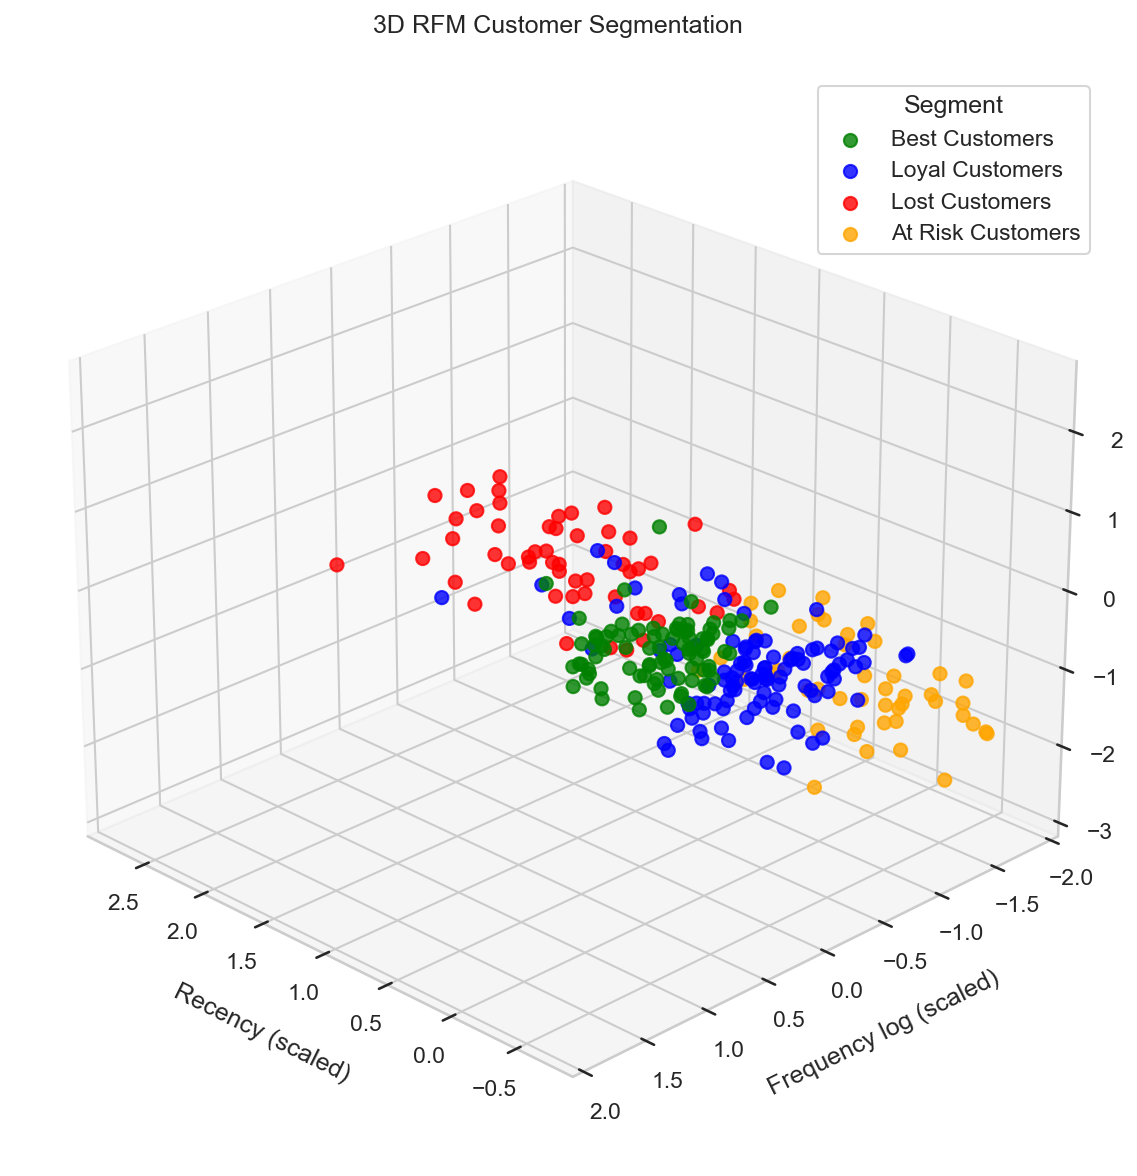

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

rfm_plot = rfm_model.reset_index(drop=True).copy()

fig = plt.figure(figsize=(11, 8), dpi=150)
ax = fig.add_subplot(111, projection="3d")

color_map = {
    "Best Customers": "green",
    "Loyal Customers": "blue",
    "Lost Customers": "red",
    "At Risk Customers": "orange"
}

for segment, color in color_map.items():
    mask = rfm_plot["Segment"] == segment

    ax.scatter(
        X_scaled[mask, 0],
        X_scaled[mask, 1],
        X_scaled[mask, 2],
        label=segment,
        color=color,
        s=40,
        alpha=0.8
    )

ax.set_title("3D RFM Customer Segmentation", pad=20)
ax.set_xlabel("Recency (scaled)", labelpad=10)
ax.set_ylabel("Frequency log (scaled)", labelpad=10)
ax.set_zlabel("Monetary log (scaled)", labelpad=10)

ax.view_init(elev=25, azim=135)
ax.legend(title="Segment")

plt.tight_layout()
plt.show()

## 12. Interpretation of the Results

The final segmentation highlights four clearly differentiated customer groups:

- `Best Customers` are the most valuable clients, with the highest purchase frequency, the highest monetary value, and the lowest recency. They should be prioritized for retention and relationship strengthening.
- `Loyal Customers` remain active and profitable, although at a lower level than the best customers. They represent a stable base that can be nurtured to increase value over time.
- `Lost Customers` are highly inactive clients with very high recency. They generated value in the past but now appear largely disengaged, which suggests churn.
- `At Risk Customers` are low-frequency and low-value customers with weakening engagement. They are not yet as inactive as lost customers, but they require attention before they decline further.

Overall, the 4-cluster solution offers a practical balance between statistical coherence and business usefulness.


## 13. Conclusion

This notebook developed an RFM-based customer segmentation using K-Means clustering on cleaned invoice data. After constructing the global RFM table and filtering low-value or one-time clients, the final model retained four business-relevant customer segments.

Although the 2-cluster solution achieved the strongest silhouette score, the 4-cluster model was selected because it provided a richer and more actionable customer structure for real business analysis. The resulting segmentation can support targeted retention, reactivation, and customer development strategies.


## 14. Yearly RFM and Cluster Exports (2024 and 2025)

This section builds separate RFM tables for 2024 and 2025, computes clusters for each year, and saves all four datasets as CSV files.


In [ ]:
# 1) Build yearly RFM tables
df_2024 = df[df["Date"].dt.year == 2024].copy()
df_2025 = df[df["Date"].dt.year == 2025].copy()

rfm_2024 = compute_rfm(df_2024)
rfm_2025 = compute_rfm(df_2025)

# 2) Build yearly cluster tables using the existing scaler + final K-Means model
def build_yearly_cluster_table(rfm_table):
    yearly_filtered = rfm_table[(rfm_table["Frequency"] >= 2) & (rfm_table["Monetary"] >= 1000)].copy()
    yearly_filtered["Frequency_log"] = np.log1p(yearly_filtered["Frequency"])
    yearly_filtered["Monetary_log"] = np.log1p(yearly_filtered["Monetary"])

    yearly_features = yearly_filtered[["Recency", "Frequency_log", "Monetary_log"]].copy()
    yearly_scaled = scaler.transform(yearly_features)

    yearly_filtered["Cluster"] = kmeans.predict(yearly_scaled)
    yearly_filtered["Segment"] = yearly_filtered["Cluster"].map(segment_map)

    return yearly_filtered

cluster_2024 = build_yearly_cluster_table(rfm_2024)
cluster_2025 = build_yearly_cluster_table(rfm_2025)

# 3) Save all four datasets
tables_output_dir = output_dir.parent / "tables"
tables_output_dir.mkdir(parents=True, exist_ok=True)

rfm_2024_path = tables_output_dir / "rfm_2024.csv"
rfm_2025_path = tables_output_dir / "rfm_2025.csv"
cluster_2024_path = tables_output_dir / "cluster_2024.csv"
cluster_2025_path = tables_output_dir / "cluster_2025.csv"

rfm_2024.to_csv(rfm_2024_path, index=False)
rfm_2025.to_csv(rfm_2025_path, index=False)
cluster_2024.to_csv(cluster_2024_path, index=False)
cluster_2025.to_csv(cluster_2025_path, index=False)

print("rfm_2024 shape:", rfm_2024.shape)
print("rfm_2025 shape:", rfm_2025.shape)
print("cluster_2024 shape:", cluster_2024.shape)
print("cluster_2025 shape:", cluster_2025.shape)
print("Saved:")
print(" -", rfm_2024_path)
print(" -", rfm_2025_path)
print(" -", cluster_2024_path)
print(" -", cluster_2025_path)


rfm_2024 shape: (265, 6)
rfm_2025 shape: (256, 6)
cluster_2024 shape: (242, 10)
cluster_2025 shape: (230, 10)
Saved:
 - c:\Users\H-Info\OneDrive\Desktop\graduation_project\facture2425 rfm model\rfm_ml_project\notebooks\outputs\tables\rfm_2024.csv
 - c:\Users\H-Info\OneDrive\Desktop\graduation_project\facture2425 rfm model\rfm_ml_project\notebooks\outputs\tables\rfm_2025.csv
 - c:\Users\H-Info\OneDrive\Desktop\graduation_project\facture2425 rfm model\rfm_ml_project\notebooks\outputs\tables\cluster_2024.csv
 - c:\Users\H-Info\OneDrive\Desktop\graduation_project\facture2425 rfm model\rfm_ml_project\notebooks\outputs\tables\cluster_2025.csv


,Cluster,Segment,Avg_Monetary,Avg_Frequency,Avg_Recency,Retention_Estimate,Estimated_Lifespan,CLV
0,2,Best Customers,"4,163,399.00",295.54,10.4,89.04%,9.12,"11,226,069,161.72"
1,0,Loyal Customers,"657,734.45",70.02,54.1,54.81%,2.21,"101,917,633.09"
2,1,Lost Customers,"241,159.67",22.75,547.2,0.23%,1.00,"5,500,112.21"
3,3,At Risk Customers,"55,771.45",6.55,148.3,19.25%,1.24,"452,597.80"


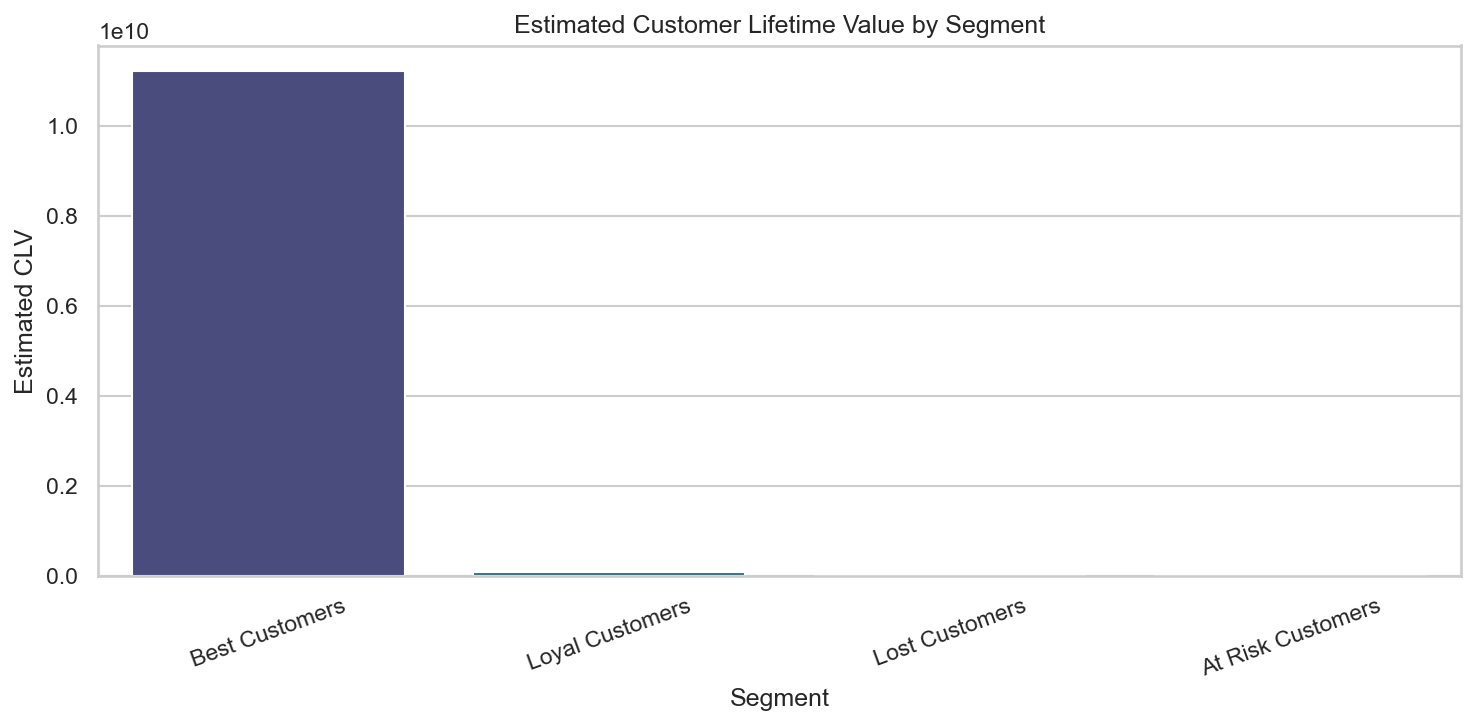

In [ ]:
# CLV estimation by cluster/segment
# Uses the existing cluster profile table when available.
if "cluster_profiles" in globals():
    clv_base = cluster_profiles.copy()
elif "segment_profile" in globals():
    clv_base = segment_profile.reset_index().copy()
else:
    clv_base = (
        rfm_model.groupby(["Cluster", "Segment"], as_index=False)
        .agg(
            Avg_Recency=("Recency", "mean"),
            Avg_Frequency=("Frequency", "mean"),
            Avg_Monetary=("Monetary", "mean")
        )
    )

# Standardize expected metric columns
if "Avg_Recency" not in clv_base.columns and "Recency" in clv_base.columns:
    clv_base["Avg_Recency"] = clv_base["Recency"]
if "Avg_Frequency" not in clv_base.columns and "Frequency" in clv_base.columns:
    clv_base["Avg_Frequency"] = clv_base["Frequency"]
if "Avg_Monetary" not in clv_base.columns and "Monetary" in clv_base.columns:
    clv_base["Avg_Monetary"] = clv_base["Monetary"]

if "Segment" not in clv_base.columns:
    clv_base["Segment"] = clv_base["Cluster"].map(segment_map) if "segment_map" in globals() else "Cluster " + clv_base["Cluster"].astype(str)

# Recency-based retention and lifespan assumptions
# retention_estimate = exp(-avg_recency / 90)
# estimated_lifespan = 1 / (1 - retention_estimate)
clv_table = clv_base[["Cluster", "Segment", "Avg_Monetary", "Avg_Frequency", "Avg_Recency"]].copy()
clv_table["Retention_Estimate"] = np.exp(-clv_table["Avg_Recency"] / 90).clip(0, 0.99)
clv_table["Estimated_Lifespan"] = 1 / (1 - clv_table["Retention_Estimate"])
clv_table["CLV"] = (
    clv_table["Avg_Monetary"]
    * clv_table["Avg_Frequency"]
    * clv_table["Estimated_Lifespan"]
)

clv_table = clv_table.sort_values("CLV", ascending=False).reset_index(drop=True)

styled_clv = (
    clv_table.style
    .format({
        "Avg_Monetary": "{:,.2f}",
        "Avg_Frequency": "{:,.2f}",
        "Avg_Recency": "{:,.1f}",
        "Retention_Estimate": "{:.2%}",
        "Estimated_Lifespan": "{:,.2f}",
        "CLV": "{:,.2f}"
    })
    .background_gradient(subset=["CLV"], cmap="YlGnBu")
)

display(styled_clv)

plt.figure(figsize=(10, 5), dpi=150)
ax = sns.barplot(data=clv_table, x="Segment", y="CLV", hue="Segment", palette="viridis", legend=False)
ax.set_title("Estimated Customer Lifetime Value by Segment")
ax.set_xlabel("Segment")
ax.set_ylabel("Estimated CLV")
plt.xticks(rotation=20)
plt.tight_layout()

fig_name = "cluster_clv_estimation"
if "save_fig" in globals():
    saved = False
    for args in [(fig_name,), (plt.gcf(), fig_name), (fig_name, output_dir), (plt.gcf(), fig_name, output_dir)]:
        try:
            save_fig(*args)
            saved = True
            break
        except TypeError:
            continue
    if not saved:
        fallback_dir = output_dir if "output_dir" in globals() else Path("outputs/figures")
        fallback_dir.mkdir(parents=True, exist_ok=True)
        plt.savefig(fallback_dir / f"{fig_name}.png", dpi=300, bbox_inches="tight")
else:
    fallback_dir = output_dir if "output_dir" in globals() else Path("outputs/figures")
    fallback_dir.mkdir(parents=True, exist_ok=True)
    plt.savefig(fallback_dir / f"{fig_name}.png", dpi=300, bbox_inches="tight")

plt.show()

